# Database schema diagram — introspect

In [1]:
from pathlib import Path
import duckdb
import polars as pl
import graphviz
from IPython.display import Image, display

DB_PATH = Path('../data/humans_clean.duckdb').resolve()
OUT_PNG = Path('../docs/schema.png').resolve()

HEADER_BG = '#2171b5'
BODY_BG   = '#f5f5f5'
JOIN_FG   = '#b5542a'
EDGE_FG   = '#7f7f7f'

assert DB_PATH.exists(), DB_PATH


## Connect

In [2]:
con = duckdb.connect(str(DB_PATH), read_only=True)


## Tables  (one row per table — name, row count, column count)

In [3]:
table_names = [
    row[0] for row in con.execute('''
        SELECT table_name
        FROM   information_schema.tables
        WHERE  table_schema = 'main'
        ORDER  BY table_name
    ''').fetchall()
]

table_rows = []
for table_name in table_names:
    n_columns = con.execute(f'SELECT COUNT(*) FROM information_schema.columns WHERE table_schema = \'main\' AND table_name = \'{table_name}\'').fetchone()[0]
    n_rows    = con.execute(f'SELECT COUNT(*) FROM "{table_name}"').fetchone()[0]
    table_rows.append({'table_name': table_name, 'n_rows': n_rows, 'n_columns': n_columns})

tables = pl.DataFrame(table_rows).sort('n_rows', descending=True)

print('shape:', tables.shape)
tables.head()


shape: (18, 3)


table_name,n_rows,n_columns
str,i64,i64
"""identifiers""",59508342,6
"""works""",38555710,12
"""wikimedia_links""",15551839,6
"""individuals""",13003420,42
"""individuals_floruit_period""",13003420,19


## Columns  (one row per (table, column))

In [4]:
columns = con.execute('''
    SELECT table_name, column_name, data_type
    FROM   information_schema.columns
    WHERE  table_schema = 'main'
    ORDER  BY table_name, ordinal_position
''').pl()

print('shape:', columns.shape)
columns.head()


shape: (199, 3)


table_name,column_name,data_type
str,str,str
"""country_of_citizenship""","""wikidata_id""","""VARCHAR"""
"""country_of_citizenship""","""name_en""","""VARCHAR"""
"""country_of_citizenship""","""count""","""BIGINT"""
"""country_of_citizenship""","""description_en""","""VARCHAR"""
"""country_of_citizenship""","""instance_of""","""VARCHAR"""


## Logical join paths  (DuckDB does not declare foreign keys, so the join paths are explicit)

In [5]:
JOIN_PATHS = [
    ('individuals_keys',                     'wikidata_id',     'individuals',          'wikidata_id'),
    ('individuals_floruit_period',           'wikidata_id',     'individuals',          'wikidata_id'),
    ('individuals_cliopatria',               'wikidata_id',     'individuals',          'wikidata_id'),
    ('individuals_cliopatria_url',           'wikidata_id',     'individuals',          'wikidata_id'),
    ('individual_writing_languages',         'wikidata_id',     'individuals',          'wikidata_id'),
    ('identifiers',                          'wikidata_id',     'individuals',          'wikidata_id'),
    ('wikimedia_links',                      'wikidata_id',     'individuals',          'wikidata_id'),
    ('works',                                'individual_id',   'individuals',          'wikidata_id'),
    ('individuals_keys',                     'birthcity_id',    'places',               'id'),
    ('individuals_keys',                     'deathcity_id',    'places',               'id'),
    ('individual_writing_languages',         'language_id',     'writing_languages',    'id'),
    ('identifiers',                          'property_id',     'identifier_types',     'property_id'),
    ('individuals_cliopatria',               'polity_id',       'polities_cliopatria',  'id'),
    ('individuals_cliopatria_url',           'polity_id',       'polities_cliopatria',  'id'),
    ('polities_periods_cliopatria',          'polity_id',       'polities_cliopatria',  'id'),
    ('polities_modern_countries_cliopatria', 'polity_id',       'polities_cliopatria',  'id'),
    ('wikidata_properties_definition',       'property_id',     'identifier_types',     'property_id'),
]

joins = pl.DataFrame(
    JOIN_PATHS,
    schema=['child_table', 'child_column', 'parent_table', 'parent_column'],
    orient='row',
)

print('shape:', joins.shape)
joins.head()


shape: (17, 4)


child_table,child_column,parent_table,parent_column
str,str,str,str
"""individuals_keys""","""wikidata_id""","""individuals""","""wikidata_id"""
"""individuals_floruit_period""","""wikidata_id""","""individuals""","""wikidata_id"""
"""individuals_cliopatria""","""wikidata_id""","""individuals""","""wikidata_id"""
"""individuals_cliopatria_url""","""wikidata_id""","""individuals""","""wikidata_id"""
"""individual_writing_languages""","""wikidata_id""","""individuals""","""wikidata_id"""


## Sanity check  (every referenced table/column must exist in the database)

In [6]:
existing_columns = set(zip(columns['table_name'].to_list(), columns['column_name'].to_list()))

for child_table, child_column, parent_table, parent_column in JOIN_PATHS:
    assert (child_table,  child_column)  in existing_columns, f'missing {child_table}.{child_column}'
    assert (parent_table, parent_column) in existing_columns, f'missing {parent_table}.{parent_column}'

print(f'{len(JOIN_PATHS)} join paths — all columns exist')


17 join paths — all columns exist


## Build the graphviz diagram  (each node = one table, edges = join paths)

In [7]:
def format_row_count(n):
    if n >= 1_000_000:
        return f'{n / 1_000_000:.1f}M rows'
    if n >= 1_000:
        return f'{n / 1_000:.1f}k rows'
    return f'{n} rows'

joined_columns_per_table = {table_name: set() for table_name in table_names}
for child_table, child_column, parent_table, parent_column in JOIN_PATHS:
    joined_columns_per_table[child_table].add(child_column)
    joined_columns_per_table[parent_table].add(parent_column)

table_columns_lookup = (
    columns.group_by('table_name')
    .agg(pl.col('column_name').alias('column_names'))
)
columns_per_table = dict(
    zip(table_columns_lookup['table_name'].to_list(),
        table_columns_lookup['column_names'].to_list())
)
rows_per_table = dict(zip(tables['table_name'].to_list(), tables['n_rows'].to_list()))


def html_node(table_name):
    column_rows = '\n'.join(
        f'<TR><TD ALIGN="LEFT"><FONT COLOR="{JOIN_FG}"><B>{column}</B></FONT></TD></TR>'
        if column in joined_columns_per_table[table_name]
        else f'<TR><TD ALIGN="LEFT">{column}</TD></TR>'
        for column in columns_per_table[table_name]
    )
    row_count_label = format_row_count(rows_per_table[table_name])
    return (
        '<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0" CELLPADDING="3">'
        f'<TR><TD BGCOLOR="{HEADER_BG}"><FONT COLOR="white"><B>{table_name}</B></FONT></TD></TR>'
        f'<TR><TD BGCOLOR="{HEADER_BG}"><FONT COLOR="white" POINT-SIZE="10">{row_count_label}</FONT></TD></TR>'
        f'{column_rows}'
        '</TABLE>>'
    )


graph = graphviz.Digraph('schema', format='png')
graph.attr(rankdir='TB', splines='spline', overlap='false', nodesep='0.4', ranksep='0.6', bgcolor='white')
graph.attr('node', shape='plaintext', fontname='Helvetica', fontsize='11')
graph.attr('edge', color=EDGE_FG, arrowsize='0.7', penwidth='1.0')

for table_name in table_names:
    graph.node(table_name, label=html_node(table_name), fillcolor=BODY_BG, style='filled')

for child_table, child_column, parent_table, parent_column in JOIN_PATHS:
    graph.edge(
        child_table, parent_table,
        taillabel=child_column, headlabel=parent_column,
        fontsize='8', fontcolor='#555555', labeldistance='2', labelangle='0',
    )




## Save to `docs/schema.png` and display inline

wrote /Users/charlesdedampierre/Desktop/Rsearch Folder/cultura_database/docs/schema.png  (411.6 kB)


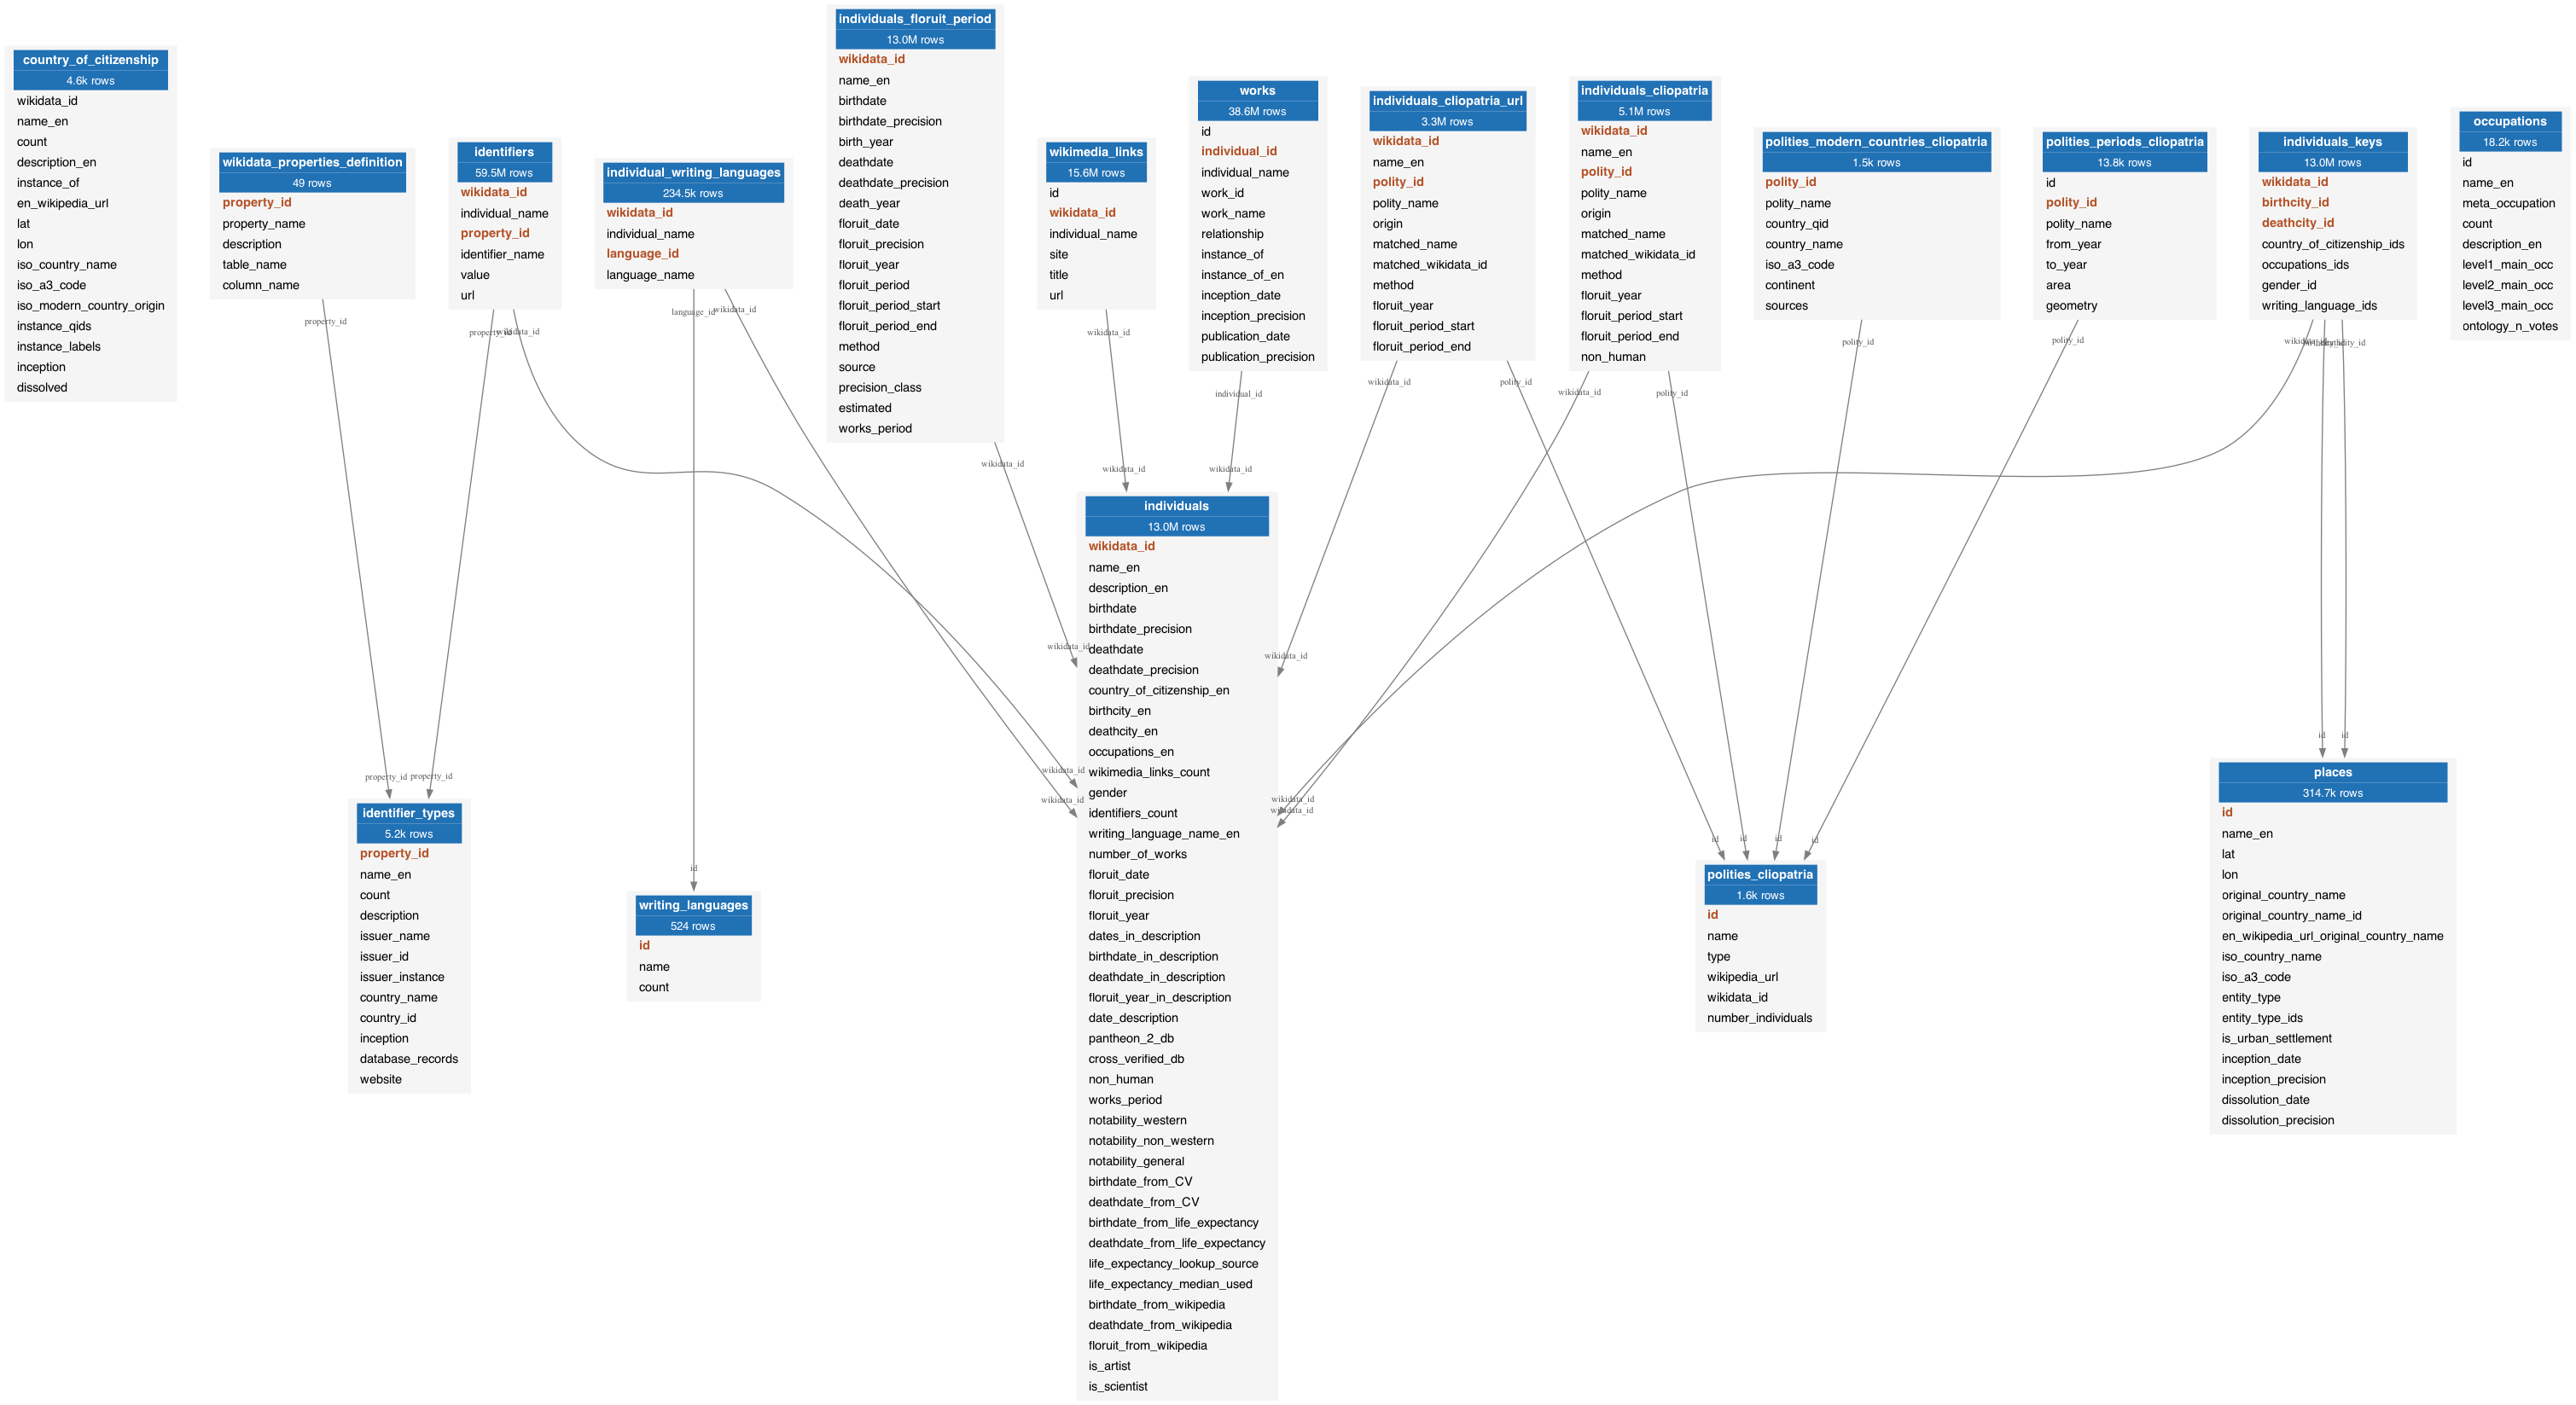

In [8]:
OUT_PNG.parent.mkdir(parents=True, exist_ok=True)
rendered_path = graph.render(
    filename=OUT_PNG.with_suffix('').name,
    directory=str(OUT_PNG.parent),
    cleanup=True,
)
Path(rendered_path).replace(OUT_PNG)

print(f'wrote {OUT_PNG}  ({OUT_PNG.stat().st_size / 1024:.1f} kB)')
display(Image(filename=str(OUT_PNG)))
